## Access Station Lucinda Jetty Daily Wetlabs-Acs (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_daily_wetlabs-acs data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_wetlabs-acs.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_daily_wetlabs_acs"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 326ms
Checked 155 packages in 3ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn(bucket_name="imos-data-lab-optimised")
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 356 ms, sys: 28.4 ms, total: 384 ms
Wall time: 997 ms


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	TIME = 17374 ;
	WAVELENGTH_a = 3531 ;
	WAVELENGTH_c = 3531 ;

variables:
	float64 HEIGHT_water_sensor() ;
		HEIGHT_water_sensor:axis = Z ;
		HEIGHT_water_sensor:long_name = nominal height above sea surface of water sensor ;
		HEIGHT_water_sensor:positive = up ;
		HEIGHT_water_sensor:reference_datum = sea surface ;
		HEIGHT_water_sensor:standard_name = height ;
		HEIGHT_water_sensor:units = metres ;
		HEIGHT_water_sensor:valid_max = 0.0 ;
		HEIGHT_water_sensor:valid_min = -50.0 ;
	float64 LATITUDE() ;
		LATITUDE:axis = Y ;
		LATITUDE:long_name = latitude ;
		LATITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LATITUDE:standard_name = latitude ;
		LATITUDE:units = degrees_north ;
		LATITUDE:valid_max = 90.0 ;
		LATITUDE:valid_min = -90.0 ;
	float64 LONGITUDE() ;
		LONGITUDE:axis = X ;
		LONGITUDE:long_name = longitude ;
		LONGITUDE:reference_datum = geographical coordinates, WGS84 projection ;
		LONGITUDE:standard_name = longitude ;
		L

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2014-01-09 05:25:00'), Timestamp('2014-12-09 23:55:00'))

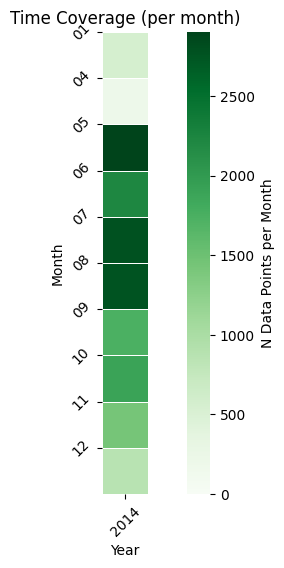

In [7]:
aodn_dataset.plot_time_coverage()

## Time Series at Key Wavelengths with Daily Statistics Envelope

The daily dataset stores **pre-computed statistics** for every spectral bin:
mean (`tsc_data_a`), standard deviation (`tsc_data_a_sd`), minimum, maximum, and number of observations.
This makes it straightforward to show the **day-to-day variability** as a ±1 σ shaded band without
any client-side aggregation.

Diagnostically important wavelengths:
- **440 nm** — dominated by CDOM and phytoplankton absorption (blue channel)
- **550 nm** — green reference; relatively low absorption, useful as a scattering proxy
- **675 nm** — near the chlorophyll-a absorption peak; phytoplankton indicator


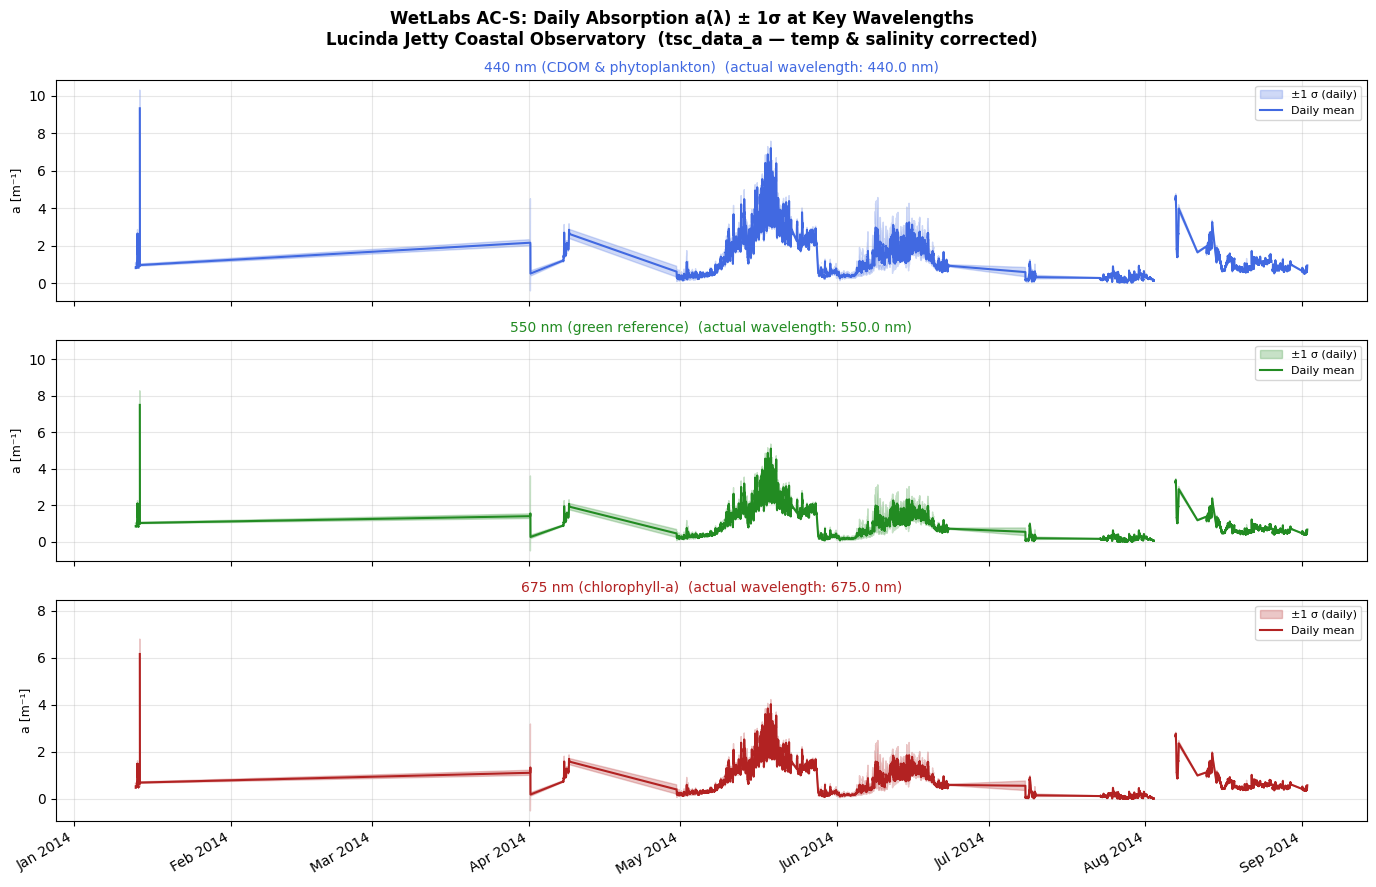

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)

wavelengths = {440: '440 nm (CDOM & phytoplankton)', 550: '550 nm (green reference)', 675: '675 nm (chlorophyll-a)'}
colors       = {440: 'royalblue', 550: 'forestgreen', 675: 'firebrick'}

fig, axes = plt.subplots(len(wavelengths), 1, figsize=(14, 9), sharex=True)

for ax, (target_wl, label) in zip(axes, wavelengths.items()):
    idx       = int(np.argmin(np.abs(wl_a - target_wl)))
    actual_wl = float(wl_a[idx])
    color     = colors[target_wl]

    a_mean = ds_sub['tsc_data_a'].isel(WAVELENGTH_a=idx).values
    a_sd   = ds_sub['tsc_data_a_sd'].isel(WAVELENGTH_a=idx).values
    n_obs  = ds_sub['tsc_data_a_num_obs'].values
    # mask days with no observations
    a_mean = np.where(n_obs > 0, a_mean, np.nan)
    a_sd   = np.where(n_obs > 0, a_sd,   np.nan)

    ax.fill_between(times, a_mean - a_sd, a_mean + a_sd,
                    alpha=0.25, color=color, label='±1 σ (daily)')
    ax.plot(times, a_mean, color=color, linewidth=1.5, label='Daily mean')
    ax.set_ylabel('a [m⁻¹]', fontsize=9)
    ax.set_title(f'{label}  (actual wavelength: {actual_wl:.1f} nm)', fontsize=10, color=color)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)
fig.suptitle(
    'WetLabs AC-S: Daily Absorption a(λ) ± 1σ at Key Wavelengths\n'
    'Lucinda Jetty Coastal Observatory  (tsc_data_a — temp & salinity corrected)',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()


## Spectral Absorption Hovmöller Diagram

A Hovmöller diagram shows **wavelength (y-axis) vs time (x-axis)** coloured by absorption magnitude.
Because this is the **daily** dataset the values are already one-per-day — no resampling is required.
The diagram reveals:

- Seasonal cycles in phytoplankton biomass (enhanced near-UV and red absorption in summer)
- CDOM pulses from river runoff (elevated short-wavelength absorption)
- Long-term optical water-quality trends


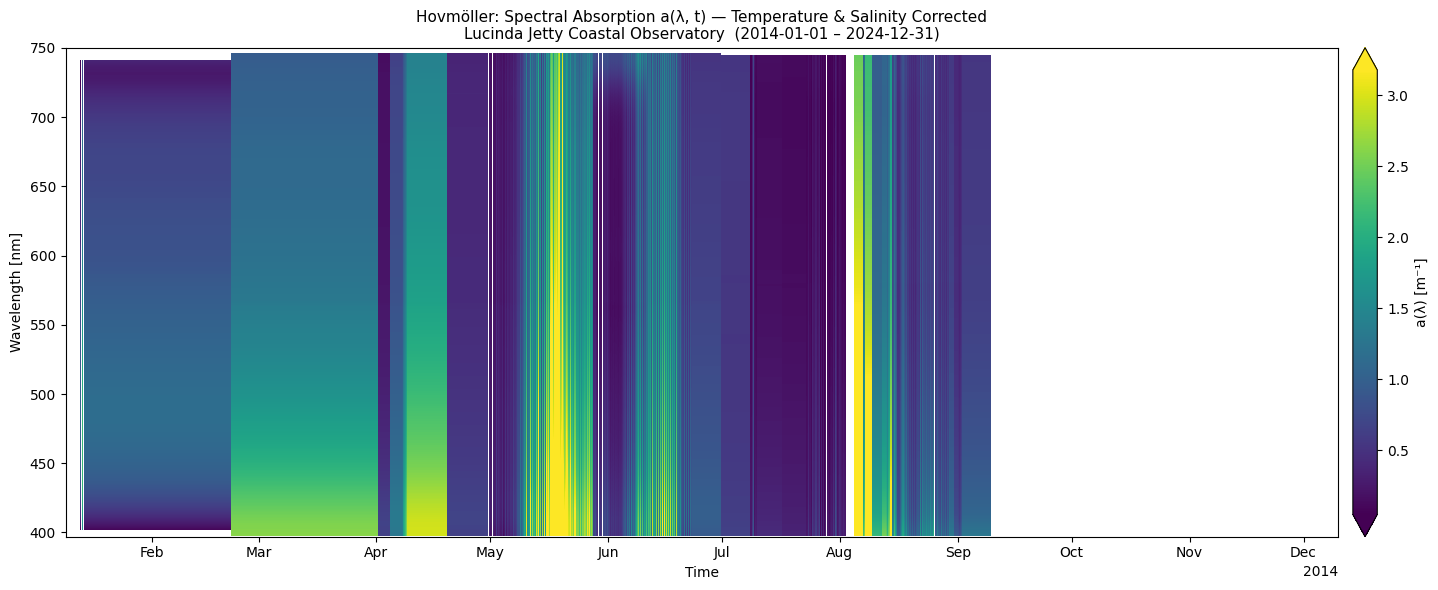

In [9]:
import numpy as np
import matplotlib.pyplot as plt

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))

# Daily data: no resample needed — use directly
# mask days with zero observations
n_obs  = ds_sub['tsc_data_a_num_obs'].values          # shape: (TIME,)
a_da   = ds_sub['tsc_data_a'].where(ds_sub['tsc_data_a_num_obs'] > 0)

fig, ax = plt.subplots(figsize=(16, 6))
a_da.plot(
    x='TIME',
    y='WAVELENGTH_a',
    cmap='viridis',
    robust=True,
    ax=ax,
    cbar_kwargs={'label': 'a(λ) [m⁻¹]', 'pad': 0.01},
)
ax.set_xlabel('Time')
ax.set_ylabel('Wavelength [nm]')
ax.set_title(
    f'Hovmöller: Spectral Absorption a(λ, t) — Temperature & Salinity Corrected\n'
    f'Lucinda Jetty Coastal Observatory  ({DATE_START} – {DATE_END})',
    fontsize=11,
)
plt.tight_layout()
plt.show()


## Processing Level Comparison: cal vs tsc vs rtc

A key advantage of the daily dataset is that all **three processing levels** are stored alongside each
other, making it easy to inspect the effect of each correction step:

| Prefix | Correction applied |
|---|---|
| `cal_data_*` | Calibration only |
| `tsc_data_*` | + Temperature & salinity correction |
| `rtc_data_*` | + Reflective tube correction (on top of tsc) |

The temperature-salinity correction is largest at shorter wavelengths where pure-water absorption is
most temperature-sensitive. Comparing the three levels shows whether optical variability is driven by
water-mass changes or by instrument/environmental artefacts.


/tmp/ipykernel_1313066/3473775071.py:49: RuntimeWarning: Mean of empty slice
  mean_spec = np.nanmean(data, axis=1)


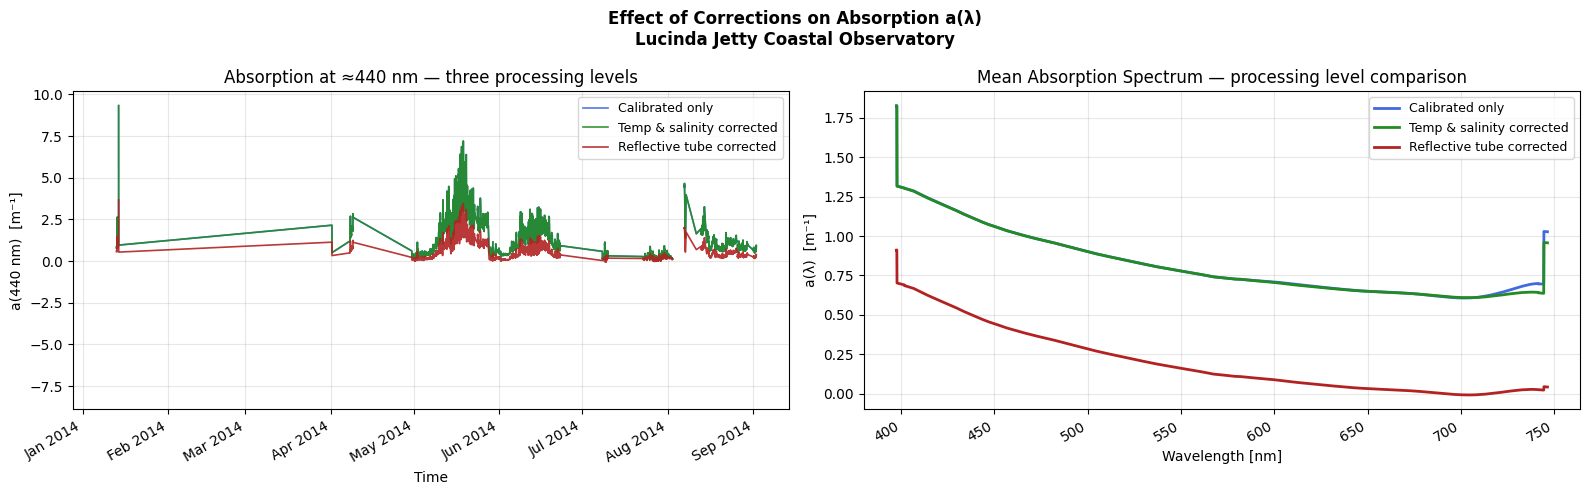

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)

idx440 = int(np.argmin(np.abs(wl_a - 440)))
wl440  = float(wl_a[idx440])

n_obs = ds_sub['tsc_data_a_num_obs'].values
valid = n_obs > 0

levels = {
    'cal_data_a':  ('Calibrated only',              'royalblue'),
    'tsc_data_a':  ('Temp & salinity corrected',    'forestgreen'),
    'rtc_data_a':  ('Reflective tube corrected',    'firebrick'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: time series at 440 nm for all three levels
for var, (label, color) in levels.items():
    vals = ds_sub[var].isel(WAVELENGTH_a=idx440).values
    vals = np.where(valid, vals, np.nan)
    ax1.plot(times, vals, linewidth=1.2, color=color, label=label, alpha=0.9)

ax1.set_xlabel('Time')
ax1.set_ylabel(f'a({wl440:.0f} nm)  [m⁻¹]')
ax1.set_title(f'Absorption at ≈440 nm — three processing levels')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)

# Panel 2: mean spectra for all three levels
for var, (label, color) in levels.items():
    data = ds_sub[var].values                   # shape: (WAVELENGTH_a, TIME)
    data = np.where(valid[np.newaxis, :], data, np.nan)
    mean_spec = np.nanmean(data, axis=1)
    ax2.plot(wl_a, mean_spec, linewidth=2, color=color, label=label)

ax2.set_xlabel('Wavelength [nm]')
ax2.set_ylabel('a(λ)  [m⁻¹]')
ax2.set_title('Mean Absorption Spectrum — processing level comparison')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(
    'Effect of Corrections on Absorption a(λ)\nLucinda Jetty Coastal Observatory',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()


## Seasonal Mean Absorption and Attenuation Spectra

Averaging spectra by Southern Hemisphere meteorological season reveals how the spectral shape of
absorption `a(λ)` and attenuation `c(λ)` changes through the year. The daily dataset provides
pre-computed standard deviations, so the shaded ±1 σ envelopes are drawn without extra computation.

- **Summer (DJF)**: warmer water, potentially higher phytoplankton and CDOM loading
- **Winter (JJA)**: cooler, typically clearer water
- **Autumn/Spring** (MAM/SON): transitional conditions


/tmp/ipykernel_1313066/2447366231.py:38: RuntimeWarning: Mean of empty slice
  mean_a = np.nanmean(a_data[:, mask], axis=1)
/tmp/ipykernel_1313066/2447366231.py:39: RuntimeWarning: Mean of empty slice
  sd_a   = np.nanmean(a_sd[:, mask],   axis=1)   # mean of within-day σ
/tmp/ipykernel_1313066/2447366231.py:40: RuntimeWarning: Mean of empty slice
  mean_c = np.nanmean(c_data[:, mask], axis=1)
/tmp/ipykernel_1313066/2447366231.py:41: RuntimeWarning: Mean of empty slice
  sd_c   = np.nanmean(c_sd[:, mask],   axis=1)


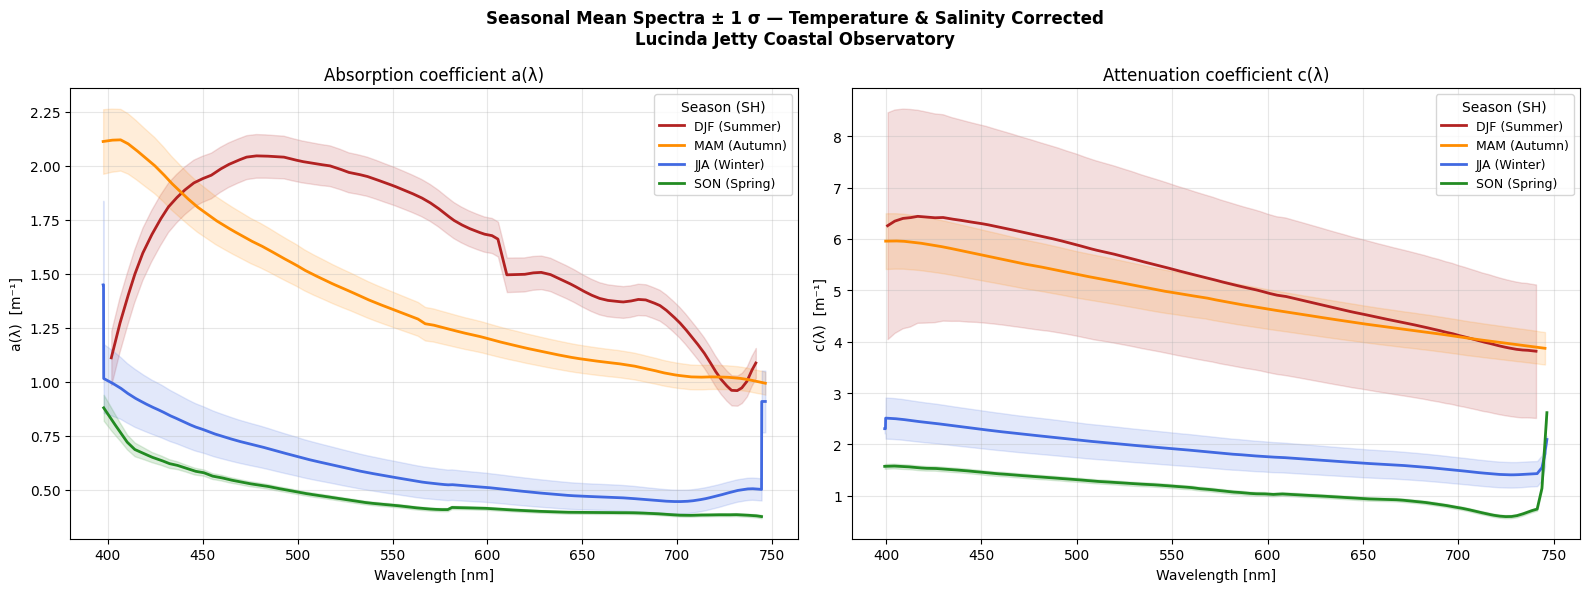

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
wl_c   = xds['WAVELENGTH_c'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)
valid  = ds_sub['tsc_data_a_num_obs'].values > 0

a_data  = np.where(valid[np.newaxis, :], ds_sub['tsc_data_a'].values,    np.nan)
a_sd    = np.where(valid[np.newaxis, :], ds_sub['tsc_data_a_sd'].values,  np.nan)
c_data  = np.where(valid[np.newaxis, :], ds_sub['tsc_data_c'].values,    np.nan)
c_sd    = np.where(valid[np.newaxis, :], ds_sub['tsc_data_c_sd'].values,  np.nan)

season_map    = {12: 'DJF (Summer)', 1: 'DJF (Summer)', 2: 'DJF (Summer)',
                  3: 'MAM (Autumn)',  4: 'MAM (Autumn)',  5: 'MAM (Autumn)',
                  6: 'JJA (Winter)',  7: 'JJA (Winter)',  8: 'JJA (Winter)',
                  9: 'SON (Spring)', 10: 'SON (Spring)', 11: 'SON (Spring)'}
season_colors = {'DJF (Summer)': 'firebrick', 'MAM (Autumn)': 'darkorange',
                 'JJA (Winter)': 'royalblue',  'SON (Spring)': 'forestgreen'}
season_order  = ['DJF (Summer)', 'MAM (Autumn)', 'JJA (Winter)', 'SON (Spring)']

seasons = times.month.map(season_map)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for season in season_order:
    mask  = seasons == season
    color = season_colors[season]
    mean_a = np.nanmean(a_data[:, mask], axis=1)
    sd_a   = np.nanmean(a_sd[:, mask],   axis=1)   # mean of within-day σ
    mean_c = np.nanmean(c_data[:, mask], axis=1)
    sd_c   = np.nanmean(c_sd[:, mask],   axis=1)
    ax1.fill_between(wl_a, mean_a - sd_a, mean_a + sd_a, alpha=0.15, color=color)
    ax1.plot(wl_a, mean_a, color=color, linewidth=2, label=season)
    ax2.fill_between(wl_c, mean_c - sd_c, mean_c + sd_c, alpha=0.15, color=color)
    ax2.plot(wl_c, mean_c, color=color, linewidth=2, label=season)

for ax, title, ylabel in [
    (ax1, 'Absorption coefficient a(λ)', 'a(λ)  [m⁻¹]'),
    (ax2, 'Attenuation coefficient c(λ)', 'c(λ)  [m⁻¹]'),
]:
    ax.set_xlabel('Wavelength [nm]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Season (SH)', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Seasonal Mean Spectra ± 1 σ — Temperature & Salinity Corrected\n'
    'Lucinda Jetty Coastal Observatory',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()


## Derived Scattering Coefficient b(λ) = c(λ) − a(λ)

The **scattering coefficient** is derived as:

> **b(λ) = c(λ) − a(λ)**

Because both `c` and `a` have independent measurement uncertainties, the propagated uncertainty is:

> **σ_b(λ) = √(σ_c(λ)² + σ_a(λ)²)**

using the pre-stored `_sd` fields from the daily dataset — no raw data needed.
At **550 nm**, where phytoplankton absorption is low, b(550) is a widely-used proxy for
**total particulate load and turbidity** — useful for monitoring resuspension events and river plumes.

> **Note**: WAVELENGTH_a and WAVELENGTH_c grids are matched index-by-index (standard AC-S practice).


/tmp/ipykernel_1313066/218347798.py:26: RuntimeWarning: Mean of empty slice
  b_mean   = np.nanmean(b,     axis=1)
/tmp/ipykernel_1313066/218347798.py:27: RuntimeWarning: Mean of empty slice
  sig_mean = np.nanmean(sig_b, axis=1)


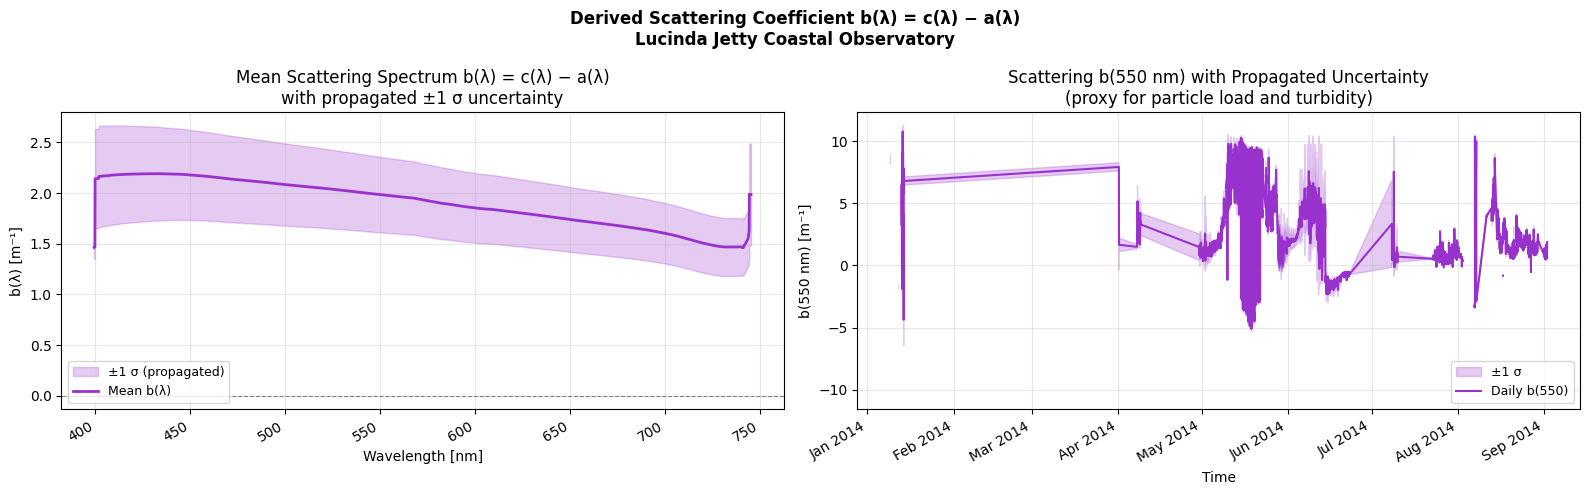

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xds = aodn_dataset.zarr_store

# --- User parameters ---
DATE_START = '2014-01-01'
DATE_END   = '2024-12-31'
# -----------------------

ds_sub = xds.sel(TIME=slice(DATE_START, DATE_END))
wl_a   = xds['WAVELENGTH_a'].values
times  = pd.DatetimeIndex(ds_sub['TIME'].values)
valid  = ds_sub['tsc_data_a_num_obs'].values > 0

a_data = np.where(valid[np.newaxis, :], ds_sub['tsc_data_a'].values,    np.nan)
c_data = np.where(valid[np.newaxis, :], ds_sub['tsc_data_c'].values,    np.nan)
a_sd   = np.where(valid[np.newaxis, :], ds_sub['tsc_data_a_sd'].values, np.nan)
c_sd   = np.where(valid[np.newaxis, :], ds_sub['tsc_data_c_sd'].values, np.nan)

b      = c_data - a_data
sig_b  = np.sqrt(c_sd**2 + a_sd**2)           # propagated uncertainty

b_mean   = np.nanmean(b,     axis=1)
sig_mean = np.nanmean(sig_b, axis=1)

idx550   = int(np.argmin(np.abs(wl_a - 550)))
wl550    = float(wl_a[idx550])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: mean ± propagated σ spectrum
ax1.fill_between(wl_a, b_mean - sig_mean, b_mean + sig_mean,
                 alpha=0.25, color='darkorchid', label='±1 σ (propagated)')
ax1.plot(wl_a, b_mean, color='darkorchid', linewidth=2, label='Mean b(λ)')
ax1.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax1.set_xlabel('Wavelength [nm]')
ax1.set_ylabel('b(λ) [m⁻¹]')
ax1.set_title('Mean Scattering Spectrum b(λ) = c(λ) − a(λ)\nwith propagated ±1 σ uncertainty')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: b(550) time series with ±σ envelope
b550   = b[idx550, :]
s550   = sig_b[idx550, :]
ax2.fill_between(times, b550 - s550, b550 + s550, alpha=0.25, color='darkorchid', label='±1 σ')
ax2.plot(times, b550, color='darkorchid', linewidth=1.5, label='Daily b(550)')
ax2.set_xlabel('Time')
ax2.set_ylabel(f'b({wl550:.0f} nm) [m⁻¹]')
ax2.set_title(f'Scattering b(550 nm) with Propagated Uncertainty\n(proxy for particle load and turbidity)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.autofmt_xdate(rotation=30)
fig.suptitle(
    'Derived Scattering Coefficient b(λ) = c(λ) − a(λ)\n'
    'Lucinda Jetty Coastal Observatory',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
plt.show()
